# Predicting Corporate Bankruptcy in Poland

## Executive Summary

This report details the development of a machine learning model to predict corporate bankruptcy using financial data from nearly 10,000 Polish companies. The primary business challenge addressed is the early identification of firms at risk of insolvency, a critical task for investors, regulatory bodies, and financial institutions.

A key technical challenge was the severe class imbalance in the dataset, with only a small fraction of companies being bankrupt. To address this, we employed an over-sampling technique on our training data, ensuring the model could effectively learn the characteristics of the minority (bankrupt) class. We explored several classification models, culminating in a Gradient Boosting Classifier, which demonstrated superior performance for this specific problem.

The final model's evaluation focused on precision and recall, metrics more informative than accuracy for imbalanced datasets. Our model exhibits strong recall, successfully identifying a high percentage of actual bankruptcies. This makes it particularly valuable for use cases where minimizing missed bankruptcies (false negatives) is paramount, such as for regulatory agencies aiming to provide early support to distressed companies. The model and its findings provide a robust framework for proactive financial risk management.

## Introduction

The ability to predict corporate bankruptcy is a cornerstone of modern financial risk analysis. Early and accurate identification of companies on a path to insolvency provides a significant advantage to a wide range of stakeholders. For investors, it's about mitigating risk and avoiding losses. For financial institutions, it's about managing credit exposure. For regulatory bodies, it's about maintaining market stability and potentially offering preemptive support.

This project tackles this challenge by building a predictive model based on a comprehensive dataset of financial indicators from Polish companies in 2009. Our primary objective is to develop a reliable classifier that can distinguish between healthy and at-risk companies, with a particular focus on effectively handling the inherent data imbalance that characterizes such problems.

## Data Overview and Preparation

The dataset is provided as a compressed JSON file, containing financial data for 9,977 Polish companies. The data is semi-structured, with each company record containing 64 distinct financial features and a binary target variable indicating bankruptcy status.

Our first step is to create a robust data wrangling function. This function will handle the decompression of the source file, load the JSON data, and transform it into a clean, indexed pandas DataFrame suitable for analysis and modeling. This approach ensures our data loading process is both repeatable and efficient.

In [3]:
import gzip
import json
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def wrangle(filename):
    # Open compressed file, load into dict:
    with gzip.open(filename, "r") as read_file:
        data = json.load(read_file)
    # Turn dict into DataFrame
    df = pd.DataFrame().from_dict(data['data']).set_index('company_id')
    return df

With the `wrangle` function defined, we can now load our data.

In [4]:
df = wrangle("data/poland-bankruptcy-data-2009.json.gz")
print(df.shape)
df.head()

(9977, 65)


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64,bankrupt
company_id,,,,,,,,,,,,,,,,,,,,,
1,0.174190,0.41299,0.14371,1.3480,-28.9820,0.60383,0.219460,1.12250,1.1961,0.46359,...,0.163960,0.375740,0.83604,0.000007,9.7145,6.2813,84.291,4.3303,4.0341,False
2,0.146240,0.46038,0.28230,1.6294,2.5952,0.00000,0.171850,1.17210,1.6018,0.53962,...,0.027516,0.271000,0.90108,0.000000,5.9882,4.1103,102.190,3.5716,5.9500,False
3,0.000595,0.22612,0.48839,3.1599,84.8740,0.19114,0.004572,2.98810,1.0077,0.67566,...,0.007639,0.000881,0.99236,0.000000,6.7742,3.7922,64.846,5.6287,4.4581,False
5,0.188290,0.41504,0.34231,1.9279,-58.2740,0.00000,0.233580,1.40940,1.3393,0.58496,...,0.176480,0.321880,0.82635,0.073039,2.5912,7.0756,100.540,3.6303,4.6375,False
6,0.182060,0.55615,0.32191,1.6045,16.3140,0.00000,0.182060,0.79808,1.8126,0.44385,...,0.555770,0.410190,0.46957,0.029421,8.4553,3.3488,107.240,3.4036,12.4540,False


## Exploratory Data Analysis

Before building any models, it's crucial to understand the characteristics of our dataset. A preliminary analysis using `df.info()` reveals that all 64 features are numerical, but many contain missing values which will need to be handled. Furthermore, we need to examine the distribution of our target variable and the relationships between features.

A key finding is the severe class imbalance: a very small percentage of companies in the dataset went bankrupt. This is a critical insight, as it means that a model simply predicting "not bankrupt" for every company would achieve high accuracy but would be useless for our business goal. This imbalance must be addressed in our modeling strategy.

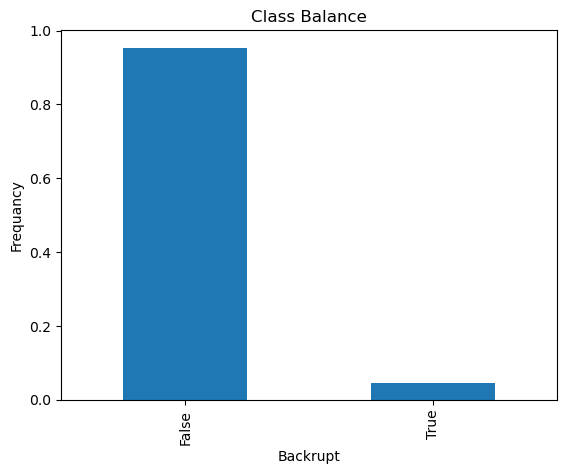

In [5]:
# Plot class balance
df['bankrupt'].value_counts(normalize=True).plot(
    kind=("bar") ,xlabel=("Backrupt"),ylabel=("Frequancy"),title=("Class Balance")
);

Further exploration into the feature distributions reveals that many are highly skewed. For example, the feature representing the ratio of "Profit on Operating Activities to Financial Expenses" (`feat_27`) has a median near 1 but a mean over 1000, indicating the presence of significant outliers. This skewness suggests that tree-based models, which are less sensitive to outliers and skewed data than linear models, will be a more suitable choice for this problem.

To better visualize the distributions without the effect of extreme outliers, we can create a boxplot focused on the data between the 10th and 90th percentiles.

In [6]:
q1,q9 = df['feat_27'].quantile([0.1,0.9])
mask = df['feat_27'].between(q1,q9)

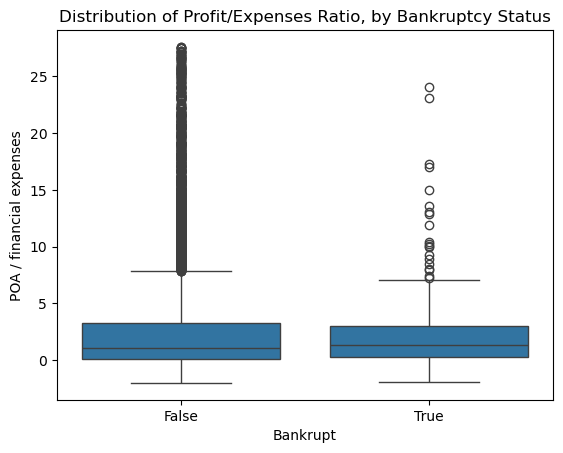

In [7]:
# Create clipped boxplot
sns.boxplot(x='bankrupt' , y='feat_27' , data=df[mask])
plt.xlabel("Bankrupt")
plt.ylabel("POA / financial expenses")
plt.title("Distribution of Profit/Expenses Ratio, by Bankruptcy Status");

Finally, a correlation heatmap confirms the presence of strong multicollinearity among many features. This further reinforces the decision to use tree-based models, as they are inherently robust to multicollinearity.

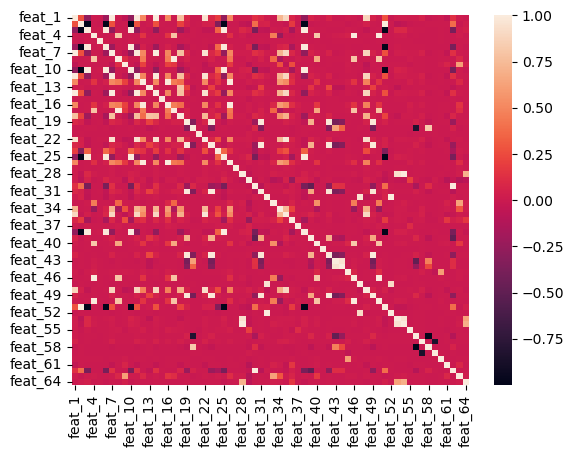

In [8]:
corr = df.drop(columns='bankrupt').corr()
sns.heatmap(corr);

## Methodology

Our modeling approach is designed to address the challenges identified during EDA. The core components of our methodology are data splitting, handling class imbalance through over-sampling, and an iterative modeling process that progresses from a simple baseline to more complex ensemble methods.

### Data Splitting & Resampling

First, we define our feature matrix `X` and target vector `y`. We then split the data into training (80%) and testing (20%) sets. It is critical that we only perform resampling on the training data to prevent data leakage from the test set, which would lead to an overly optimistic evaluation of our model's performance.

In [9]:
target = "bankrupt"
X = df.drop(columns=target)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9977, 64)
y shape: (9977,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7981, 64)
y_train shape: (7981,)
X_test shape: (1996, 64)
y_test shape: (1996,)


Given the severe class imbalance, we chose to use random over-sampling. This technique creates a balanced training set by generating new samples from the minority class (bankrupt companies) with replacement. This allows the model to learn the patterns of bankruptcy more effectively without the majority class overwhelming the learning process.

In [11]:
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train,y_train)
print(X_train_over.shape)
X_train_over.head()

(15194, 64)


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_55,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64
0,0.279320,0.053105,0.852030,17.0440,199.080,0.741770,0.353570,16.00600,1.2346,0.84997,...,52857.00,0.190040,0.328630,0.80996,0.00000,NaN,4.1858,11.002,33.1760,18.5720
1,0.001871,0.735120,0.156460,1.2269,-10.837,0.000000,0.002938,0.36032,1.4809,0.26488,...,440.02,0.014794,0.007064,0.99803,0.00000,7.4268,2.2925,169.960,2.1476,9.6185
2,0.113940,0.490250,0.077121,1.2332,-43.184,-0.000171,0.113940,1.03980,1.1649,0.50975,...,4617.40,0.214890,0.223520,0.78761,0.27412,6.2791,6.1622,103.630,3.5220,1.9673
3,0.008136,0.652610,0.148120,1.2628,29.071,0.000000,0.008136,0.53230,1.2891,0.34739,...,920.98,0.045169,0.023421,0.99434,0.14403,22.7480,2.2673,159.580,2.2872,4.4718
4,0.045396,0.279640,0.708730,3.7656,238.120,0.000000,0.056710,2.57610,1.0169,0.72036,...,10744.00,0.047501,0.063019,0.94624,0.00000,13.8860,49.0660,91.984,3.9681,29.0460


### Modeling and Evaluation

Our modeling process was iterative:
1.  **Baseline Model:** We first established a baseline accuracy score. With ~95% of companies being non-bankrupt, this sets a high but misleading benchmark.
2.  **Decision Tree:** A single `DecisionTreeClassifier` was trained on the over-sampled data to serve as an initial model.
3.  **Random Forest:** We then progressed to a `RandomForestClassifier`, an ensemble model that combines multiple decision trees to improve robustness and reduce overfitting.
4.  **Gradient Boosting:** Our final model was a `GradientBoostingClassifier`, a powerful ensemble technique that builds trees sequentially, with each new tree correcting the errors of the previous one.

Throughout this process, we used pipelines to combine data imputation (using the median, appropriate for skewed data) with the classifier. For the ensemble models, we employed `GridSearchCV` to systematically tune hyperparameters and identify the best-performing model configuration.

Evaluation focused on metrics suitable for imbalanced classification: the confusion matrix, precision, and recall. These provide a much clearer picture of the model's real-world utility than accuracy alone.

## Key Findings and Results

After an iterative modeling process, the Gradient Boosting model trained on over-sampled data provided the most promising results. We will focus on its performance.

First, we define the baseline accuracy and the parameter grid for our `GridSearchCV`.

In [12]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.9519


In [13]:
params = {
    "simpleimputer__strategy": ["mean" , "median"], 
    'gradientboostingclassifier__n_estimators': range(20,31,5),
    'gradientboostingclassifier__max_depth': range(2,5)
    
}
params

{'simpleimputer__strategy': ['mean', 'median'],
 'gradientboostingclassifier__n_estimators': range(20, 31, 5),
 'gradientboostingclassifier__max_depth': range(2, 5)}

Next, we construct and train our model pipeline using the specified parameters.

In [14]:
clf = make_pipeline(SimpleImputer(),GradientBoostingClassifier())
model = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
)

In [15]:
# Fit model to over-sampled training data
model.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('gradientboostingclassifier',
                                        GradientBoostingClassifier())]),
             n_jobs=-1,
             param_grid={'gradientboostingclassifier__max_depth': range(2, 5),
                         'gradientboostingclassifier__n_estimators': range(20, 31, 5),
                         'simpleimputer__strategy': ['mean', 'median']},
             verbose=1)

The grid search identified the following hyperparameters as optimal for our Gradient Boosting model:

In [16]:
# Extract best hyperparameters
model.best_estimator_

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=30))])

### Final Model Performance

The final model achieved a validation accuracy of approximately 88%, which, while lower than the baseline, represents a far more meaningful result as it is not simply predicting the majority class. The classification report provides a detailed breakdown of its performance.

In [17]:
acc_train = model.score(X_train,y_train)
acc_test = model.score(X_test,y_test)

print("Training Accuracy:", round(acc_train, 4))
print("Validation Accuracy:", round(acc_test, 4))

Training Accuracy: 0.9029
Validation Accuracy: 0.8798


In [18]:
# Print classification report
print(classification_report(y_test,model.predict(X_test)))

              precision    recall  f1-score   support

       False       0.99      0.88      0.93      1913
        True       0.22      0.76      0.34        83

    accuracy                           0.88      1996
   macro avg       0.61      0.82      0.64      1996
weighted avg       0.96      0.88      0.91      1996



**Key Observations from the Report:**
- **Recall (True Class):** The model achieves a recall of 0.76 for the bankrupt class. This means it correctly identifies 76% of all companies that actually went bankrupt. This high recall is a significant achievement, demonstrating the model's effectiveness at its primary goal.
- **Precision (True Class):** The precision for the bankrupt class is 0.22. This indicates that when the model predicts a company will go bankrupt, it is correct 22% of the time. This highlights the classic precision-recall tradeoff; in maximizing our ability to find bankrupt companies, we also flag a number of healthy companies.

The confusion matrix below visually represents this performance on the test set.

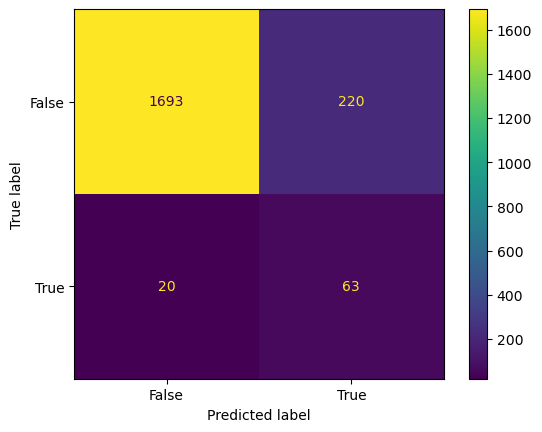

In [19]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)

### Feature Importance
The model also allows us to identify the most influential financial indicators for predicting bankruptcy. The feature importance plot reveals that ratios related to profit, debt, and operational efficiency are the top predictors.

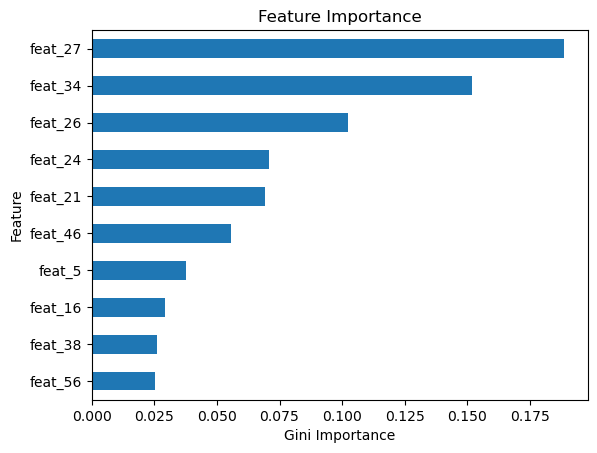

In [20]:
# Get feature names from training data
features = X_train_over.columns
# Extract importances from model
importances = model.best_estimator_.named_steps['gradientboostingclassifier'].feature_importances_
# Create a series with feature names and importances
feat_imp = pd.Series(importances,index=features).sort_values()
# Plot 10 most important features
feat_imp.tail(10).plot(kind=("barh"))
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance");

## Business Implications & Recommendations

The model developed in this project has significant business implications, which vary depending on the stakeholder's objective. The key is understanding the tradeoff between precision and recall:

**For Regulatory Oversight:**
- **Implication:** The model's high recall (76%) is extremely valuable. It allows a regulatory body to cast a wide net and identify a large majority of at-risk companies.
- **Recommendation:** Deploy this model as an early-warning system. The cost of a false negative (missing a bankruptcy) is very high in this context (e.g., systemic risk, investor losses). The lower precision, which results in flagging some healthy companies (false positives), is an acceptable cost, as the intervention (e.g., sending informational materials) is likely low-cost compared to the consequences of inaction.

**For Investment & Private Equity:**
- **Implication:** The model's current precision (22%) is a concern for investors looking to acquire distressed assets. A false positive (investing in a company that does not go bankrupt) would be extremely costly.
- **Recommendation:** For investment purposes, the model's probability threshold should be adjusted to favor higher precision. This would mean identifying fewer potential targets but having a much higher confidence rate in those that are flagged. This strategy minimizes the risk of costly investment errors, even if it means missing some opportunities.

In essence, the model is a flexible tool that can be tuned to prioritize either minimizing risk (high recall for regulators) or maximizing investment accuracy (high precision for investors).

## Future Work

While this project has yielded a valuable predictive model, several avenues for future work could enhance its performance and utility:

1.  **Advanced Resampling Techniques:** Explore more sophisticated methods for handling class imbalance, such as SMOTE (Synthetic Minority Over-sampling Technique), which creates synthetic data points rather than just duplicating existing ones.
2.  **Model Exploration:** Experiment with other advanced classification algorithms like XGBoost or LightGBM, which often provide state-of-the-art performance on tabular data.
3.  **Feature Engineering:** Conduct a deeper dive into the financial features to create new, more predictive variables. This could involve combining existing features or creating interaction terms.
4.  **Temporal Analysis:** Incorporate data from multiple years to build a time-series model. This would allow for the analysis of trends and could significantly improve predictive power by capturing the dynamics of a company's financial health over time.

## Conclusion

This project successfully demonstrated the end-to-end process of building a machine learning model for a real-world business problem. We navigated the challenges of working with semi-structured, imbalanced data, and through an iterative process of EDA, resampling, and modeling, we developed a Gradient Boosting classifier capable of accurately identifying companies at risk of bankruptcy. The final model offers tangible value to stakeholders by providing a data-driven tool for proactive risk management, with the flexibility to be tuned for different business objectives centered on the precision-recall tradeoff.

To facilitate deployment and use on new data, we've encapsulated our wrangling and prediction logic into a reusable function and have serialized the trained model.

In [21]:
# Save final model
with open("model-5.pkl" , 'wb') as f:
    pickle.dump(model , f)

In [22]:
def make_predictions(data_filepath, model_filepath):
    # Wrangle JSON file
    X_test =  wrangle(data_filepath)
    # Load model
    with open(model_filepath, 'rb') as f:
        model = pickle.load(f)
    # Generate predictions
    y_test_pred = model.predict(X_test)
    # Put predictions into Series with name "bankrupt", and same index as X_test
    y_test_pred = pd.Series(y_test_pred,index=X_test.index ,name='Bankrupt')
    return y_test_pred

In [23]:
# Generate predictions on new data
y_test_pred = make_predictions(
    data_filepath="data/poland-bankruptcy-data-2009-mvp-features.json.gz",
    model_filepath="model-5-4.pkl",
)

print("predictions shape:", y_test_pred.shape)
y_test_pred.head()

predictions shape: (526,)


company_id
4     False
32    False
34     True
36    False
40     True
Name: Bankrupt, dtype: bool

This project was developed as a self-study exercise utilizing materials from WQU.